In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import csv
import corner
import os
import glob
import pandas as pd

from mcmc import *

from astropy.io import fits
from numpy.typing import NDArray
from typing import Union
from nn_helpers import MoogStokesNN, ParamScaler
from spectra import SpectralDataForMoogStokes, MoogStokesModel, setup_regions_plot

In [101]:
data_path = "data/science"
#results = load_mcmc_results("170-337", data_path)
results = load_mcmc_results("170-337_2", data_path)

results = load_mcmc_results("158-323_errscale_2", data_path)


flat_samples = results["flat_samples"]
labels = ["Teff", "logg", "rK", "B", "vsini"]


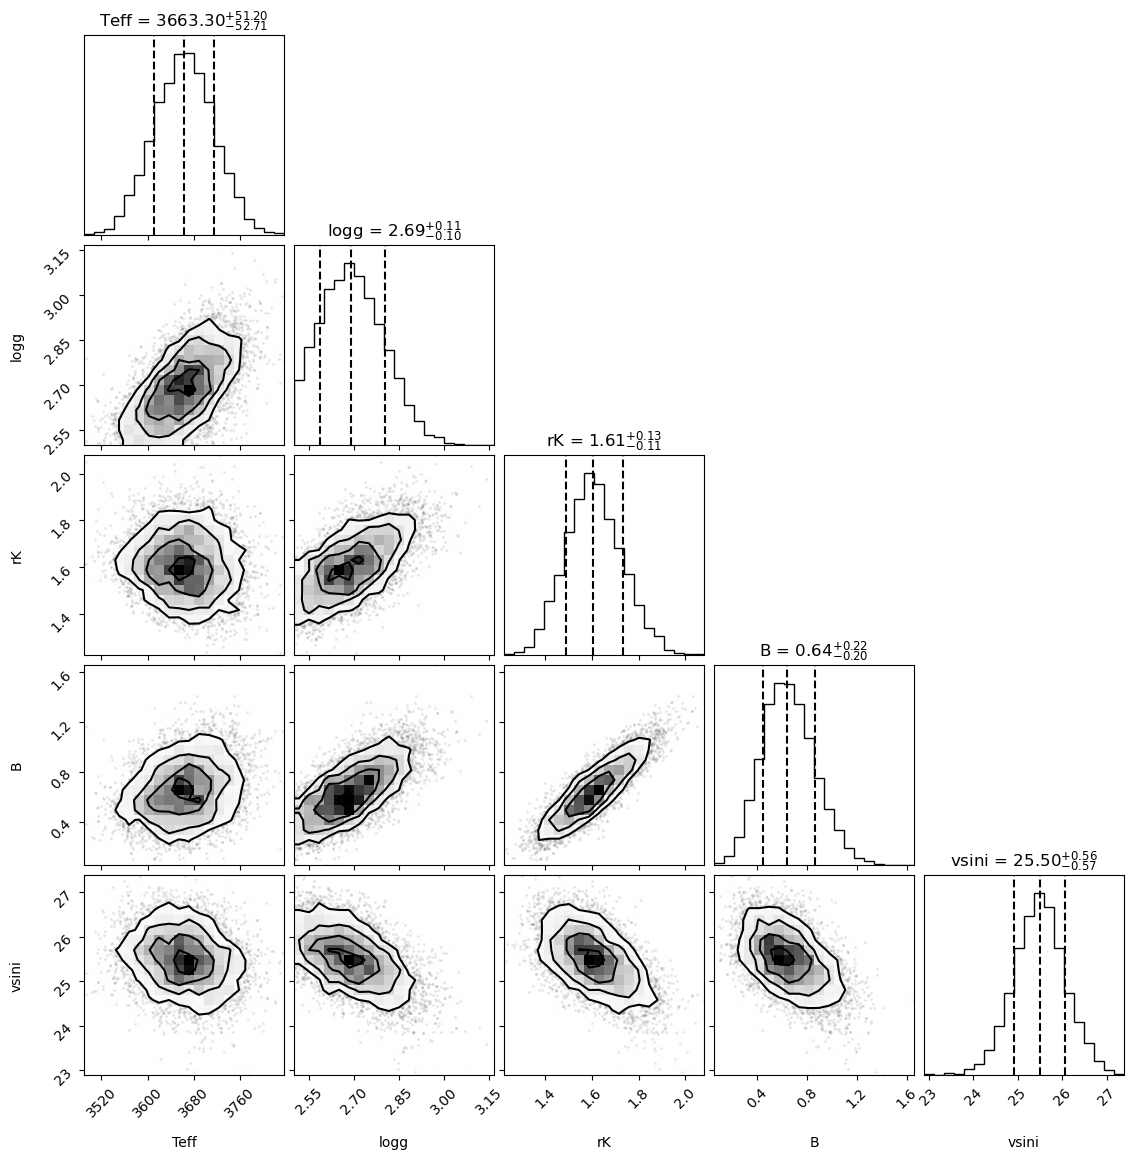

In [102]:
# Get truths as percentiles
medians = results["medians"]

fig = corner.corner(
    flat_samples, labels=labels,
    quantiles = [0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12}
)

[Nyquist sampling] Factor applied: 3. Old SNR = 97.62894011645065
[Nyquist sampling] Factor applied: 3. New SNR = 168.4993444939402


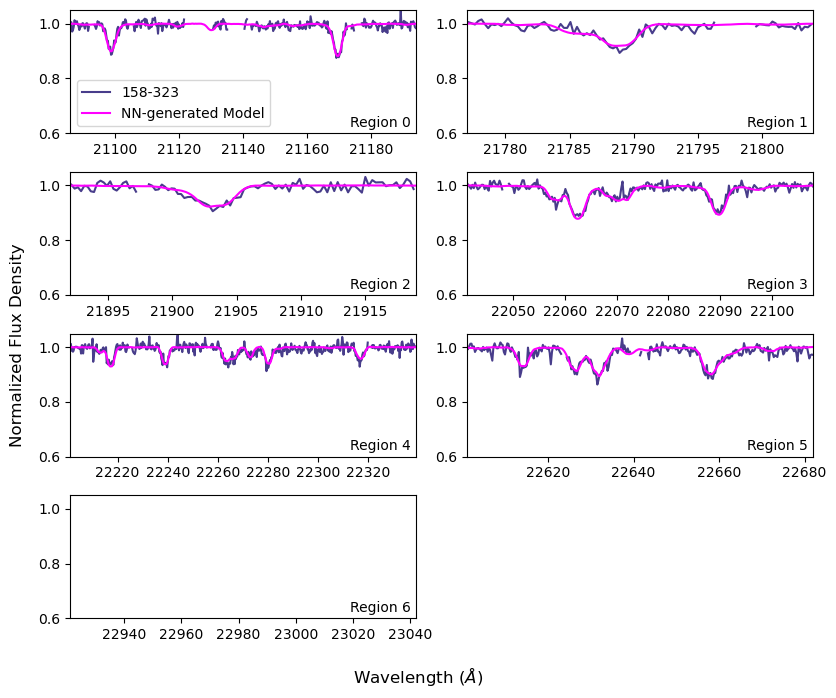

In [103]:
fig, axs = setup_regions_plot()
fname = os.path.join(data_path, results["basename"])
name = results["basename"].split(".")[0]
testdata = retrieve_spectrum_preproc(results["basename"])
moognn = MoogStokesNN()

for r in testdata.regions:
    x, y, yerr = testdata.get_region(r)
    axs[r].plot(x, y, label=testdata.name, color="darkslateblue")
    fitted_model = moognn.make_moogstokes_model(Teff=medians[0], logg=medians[1], rK=medians[2], B=medians[3], vsini=medians[4], region=r)
    axs[r].plot(fitted_model.x, fitted_model.y, label="NN-generated Model", color="fuchsia")
    axs[r].set_ylim(0.6, 1.05)

    if r == 0:
        axs[r].legend()

plt.show()

[Nyquist sampling] Factor applied: 3. Old SNR = 100.65399419718126
[Nyquist sampling] Factor applied: 3. New SNR = 174.0250955678374


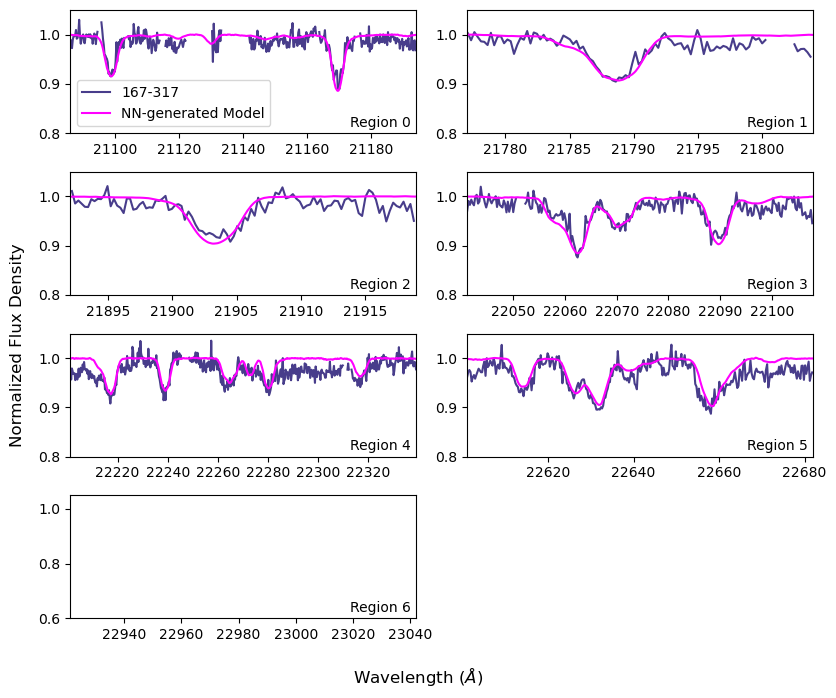

In [79]:
fig, axs = setup_regions_plot()
fname = os.path.join(data_path, results["basename"])
name = results["basename"].split(".")[0]
testdata = retrieve_spectrum_preproc(results["basename"])
moognn = MoogStokesNN()

for r in testdata.regions:
    x, y, yerr = testdata.get_region(r)
    axs[r].plot(x, y, label=testdata.name, color="darkslateblue")
    fitted_model = moognn.make_moogstokes_model(Teff=medians[0], logg=medians[1], rK=medians[2], B=medians[3], vsini=medians[4], region=r)
    axs[r].plot(fitted_model.x, fitted_model.y, label="NN-generated Model", color="fuchsia")
    axs[r].set_ylim(0.8, 1.05)

    if r == 0:
        axs[r].legend()

plt.show()

In [104]:
param_scaler = ParamScaler()
PARAM_NAMES = ["Teff", "logg", "rK", "B", "vsini"]

rows = []
for fpath in glob.glob("data/science/*_mcmc.fits"):
    # 2 is no CO, no vsini. 3 is no CO, with vsini. errscale is no CO, no vsini, also scaled errors.
    # errscale_2 is no CO, with vsini.

    # if ("_3_mcmc" in fpath or "_2_mcmc" in fpath or "_errscale" in fpath):
    #     continue

    # if "_3_mcmc" not in fpath:
    #     continue

    if not "_errscale_2_mcmc" in fpath:
        continue

    with fits.open(fpath) as hdul:
        name    = hdul["MEDIANS"].header["NAME"]
        name = name.split("_")[0]
        medians = hdul["MEDIANS"].data
        errs    = hdul["ERRS"].data  # shape (2, n_params): [16th, 84th]

    row = {"name": name}
    for i, param in enumerate(PARAM_NAMES):
        row[param]                  = medians[i]
        row[f"{param}_err_minus"]   = medians[i] - errs[0, i]  # 16th
        row[f"{param}_err_plus"]    = errs[1, i] - medians[i]  # 84th
    rows.append(row)

cols = ["name"] + PARAM_NAMES + \
       [f"{p}_err_minus" for p in PARAM_NAMES] + \
       [f"{p}_err_plus"  for p in PARAM_NAMES]

with open("data/science/mcmc_summary.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=cols)
    writer.writeheader()
    writer.writerows(rows)

/var/folders/pv/dz5xq3sj059bg3y61lpq5r4r0000gn/T/ipykernel_21821/1748646441.py:117: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


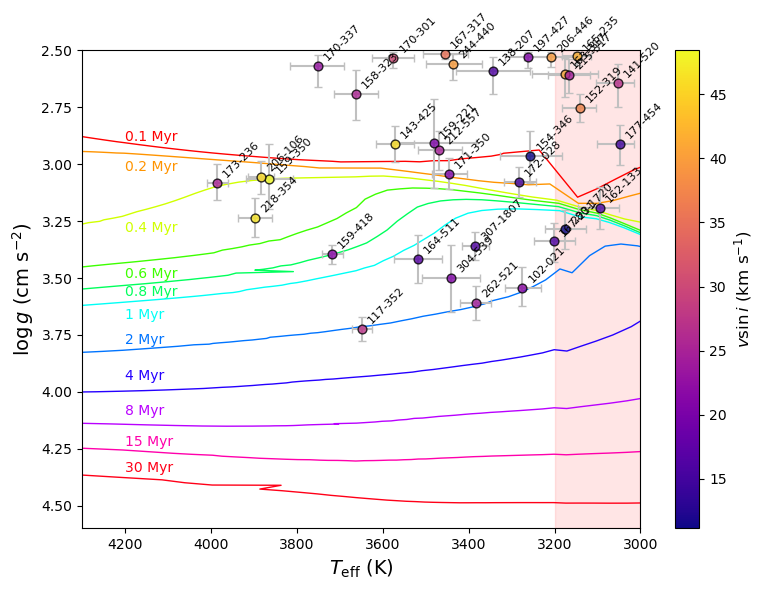

In [105]:
# Import isochrones
model_ages = [0.1, 0.2, 0.4, 0.6, 0.8, 1, 2, 4, 8, 15, 30]          # in Myr
iso_models = []
iso_path = "data/isochrones/"
csv_fname = "data/science/mcmc_summary.csv"   # adjust as needed
show_labels = True

for num in model_ages:
    fname = os.path.join(
        iso_path,
        f"dmestar_{float(num):07.1f}myr_z+0.00_a+0.00_gs98_phx_magBeq.iso"
    )

    arr = np.loadtxt(fname, skiprows=5).T
    m = arr[0]
    teff = 10**arr[1]      # convert from logTeff to Teff
    logg = arr[2]
    iso_models.append([m, teff, logg])

mass_path = "data/mass-tracks/"
masses = [0.1, 0.2, 0.4, 0.8, 1.0]
mass_tracks = []

for m in masses:
    fname = os.path.join(
        mass_path,
        f"m{ str( int(m*1000) ).zfill(4) }_GS98_p000_p0_y28_mlt1.884_magBeq.trk"
    )

    arr = np.loadtxt(fname, skiprows=4).T
    age = arr[0]
    teff = 10**arr[1]      # convert from logTeff to Teff
    logg = arr[2]
    mass_tracks.append([age, teff, logg])

# Plot isochrones
fig, ax = plt.subplots(figsize=(8, 6))
n = len(model_ages)
#tshifts = [0, 0.02, 0.02, 0, -0.04, -0.09, -0.14]
tshifts = [0, -0.03, 0.08, 0.12, 0.04, -0.02, -0.07, -0.07, -0.08, -0.1, -0.15]
#mpl.rcParams['axes.prop_cycle'] = mpl.cycler("color", plt.cm.magma(np.linspace(0,1,5))) 
colors = plt.cm.hsv(np.linspace(0, 1, n))

for i in range(len(model_ages)):
    line, = ax.plot(
        iso_models[i][1],
        iso_models[i][2],
        zorder=1,
        linewidth=1,
        c=colors[i]
    )
    ax.text(
        4200,
        2.9 + 0.16 * i + tshifts[i],
        f"{model_ages[i]} Myr",
        c=line.get_color(),
        zorder=1
    )

# for i in range(len(mass_tracks)):
#     ax.plot(
#         mass_tracks[i][1],
#         mass_tracks[i][2],
#         zorder=1,
#         linewidth=1,
#         c='gray',
#     )
    # ax.text(
    #     4500,
    #     3 + 0.16 * i + tshifts[i],
    #     f"{model_ages[i]} Myr",
    #     c=colors[i],
    #     zorder=1
    # )

ax.set_xlabel(r"$T_{\mathrm{eff}}$ (K)", fontsize=14)
ax.set_ylabel(r"$\log g$ (cm s$^{-2}$)", fontsize=14)
#ax.set_ylabel(r"$\log g$ (dex)", fontsize=14)
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_ylim(4.6, 2.5)
ax.set_xlim(4300, 3000)

# ------------------------------------------------------------------
# Plot objects from CSV
# ------------------------------------------------------------------

df = pd.read_csv(csv_fname)

for _, row in df.iterrows():
    Teff = row["Teff"]
    logg = row["logg"]

    xerr = [[row["Teff_err_minus"]], [row["Teff_err_plus"]]]
    yerr = [[row["logg_err_minus"]], [row["logg_err_plus"]]]

    ax.errorbar(
        Teff,
        logg,
        xerr=xerr,
        yerr=yerr,
        c="silver",
        capsize=3,
        zorder=2
    )

    # Color by vsini value
    if "vsini" in df.columns:
        vsini = row["vsini"]
        # Map vsini to a color (e.g., using a colormap)
        cmap = plt.cm.plasma
        norm = plt.Normalize(df["vsini"].min(), df["vsini"].max())
        color = cmap(norm(vsini))
    else:
        color = "k"
    
    ax.scatter(
        Teff,
        logg,
        c=color,
        # marker="*",
        #s=150,
        s=40,
        edgecolors='k',
        zorder=3,
        alpha=0.8
    )

    # Optional: label objects
    if "name" in df.columns and show_labels:
        ax.text(
            Teff - 10,
            logg - 0.015,
            row["name"],
            fontsize=8,
            zorder=4,
            rotation=45,
            va='bottom',
            ha='left'
        )

plt.axvspan(3000, 3200, color='r', alpha=0.1, zorder=0)

cmap = plt.cm.plasma
norm = plt.Normalize(df["vsini"].min(), df["vsini"].max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for standalone ScalarMappable
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$v \sin i$ (km s$^{-1}$)", fontsize=12)

plt.tight_layout()
plt.show()


## ADD MASS TRACKS!

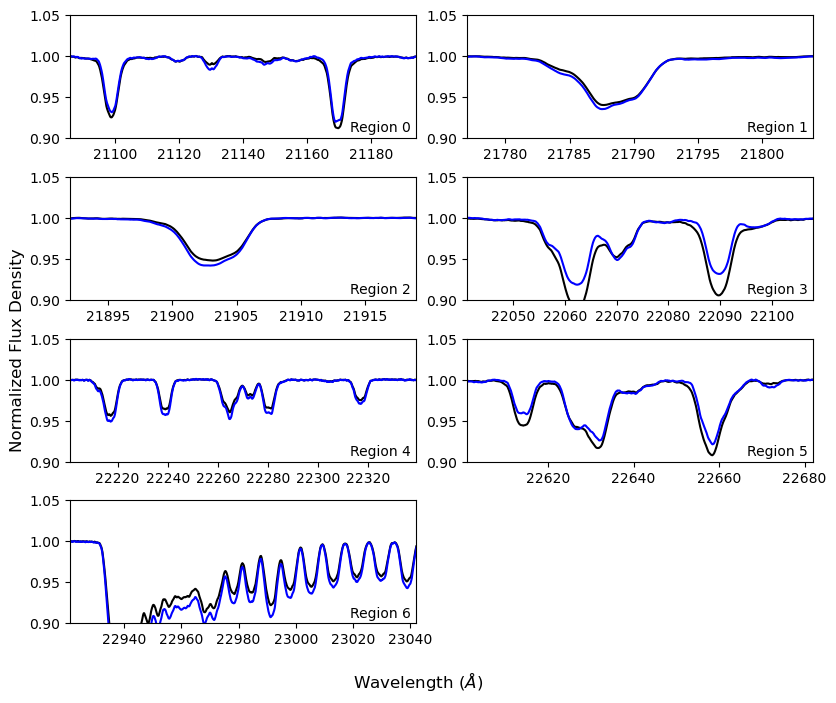

In [14]:
moognn = MoogStokesNN()

Teff = 3600
logg = 3.74
rK = 1.87
B = 1
vsini = 40

fig, axs = setup_regions_plot()
for r in range(7):
    testmodel = moognn.make_moogstokes_model(Teff=Teff, logg=3.5, rK=rK, B=B, vsini=vsini, region=r)
    axs[r].plot(testmodel.x, testmodel.y, label="Model", color="k")

    testmodel = moognn.make_moogstokes_model(Teff=Teff, logg=2.5, rK=rK, B=B, vsini=vsini, region=r)
    axs[r].plot(testmodel.x, testmodel.y, label="Model", color="b")
    axs[r].set_ylim(0.9, 1.05)

plt.show()

In [117]:
data = np.loadtxt("data/science/164-511.merged.cleaned.nspec")
x, y, yerr = data.T

In [108]:
yerr

array([0.07088425, 0.07057542, 0.07070463, ..., 0.03206179, 0.03206179,
       0.03206179], shape=(33130,))

In [120]:
testdata = retrieve_spectrum_preproc("164-511.merged.cleaned.nspec")

[Nyquist sampling] Factor applied: 3. Old SNR = 36.545406095974116
[Nyquist sampling] Factor applied: 3. New SNR = 62.99650358969227


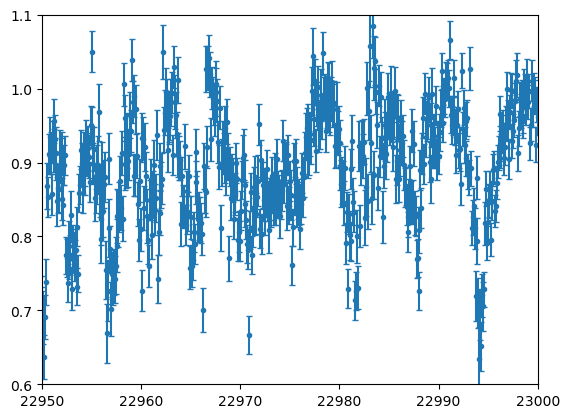

In [119]:
plt.figure()
plt.errorbar(x, y, yerr=yerr, fmt='o', markersize=3, capsize=2)
plt.xlim(2.295e4,2.30e4)
plt.ylim(0.6, 1.1)
plt.show()

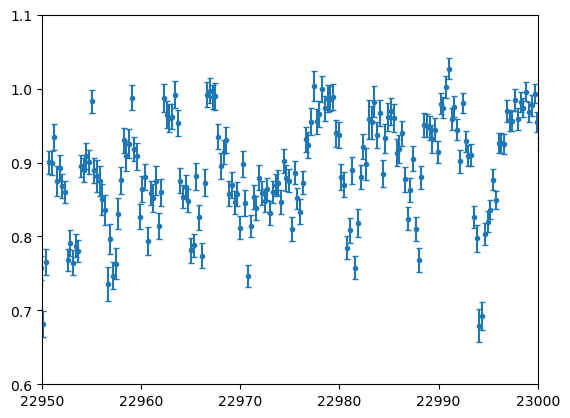

In [121]:
plt.figure()
plt.errorbar(testdata.x, testdata.y, yerr=testdata.yerr, fmt='o', markersize=3, capsize=2)
plt.xlim(2.295e4,2.30e4)
plt.ylim(0.6, 1.1)
plt.show()